<a href="https://colab.research.google.com/github/fbdasilva/QA_PHA/blob/main/Fabiany_Silva_MVP.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# MVP — Machine Learning & Analytics

**Nome:** Fabiany Bento da Silva  
**Matrícula:** _4052026000848_  
**Data:** _31/10/1996_  
**Dataset:** _Palmer Penguins (https://www.kaggle.com/datasets/malanep/palmer-penguine)_  
**Tipo de problema:** _Classificação_  


# 1. Definição do problema

## 1.1 Descrição do problema

_O projeto foi desenvolvido a partir do conjunto de dados Palmer Penguins, composto por informações coletadas na Estação Palmer, localizada na Antártica, contendo características morfológicas de diferentes espécies de pinguins, como comprimento e profundidade do bico, comprimento da nadadeira, massa corporal e sexo. Com base nessas informações, foi construída uma solução de aprendizado de máquina com o objetivo de realizar a classificação automática da espécie de um indivíduo._

_Dessa forma, o modelo apoia a tomada de decisão ao prever a qual espécie pertence um determinado pinguim a partir de suas características físicas. Os principais interessados nessa solução são pesquisadores, biólogos, ecologistas e instituições que atuam no monitoramento da fauna antártica, pois a classificação automatizada pode agilizar a identificação de novos indivíduos, reduzir o tempo necessário para análises e minimizar possíveis erros humanos. Além disso, esse tipo de abordagem é relevante para estudos de biodiversidade, conservação das espécies e monitoramento ambiental, permitindo que grandes volumes de dados sejam analisados de forma mais rápida e consistente, contribuindo para pesquisas científicas e para a preservação dos ecossistemas antárticos._


## 1.2 Objetivo do MVP

**Objetivo deste trabalho:**  
>  _O objetivo deste MVP é construir e avaliar modelos de Machine Learning para classificação da espécie de indivíduos de pinguins a partir de diferentes modelos de classificação._


# 2. Ambiente, bibliotecas e reprodutibilidade

Esta seção deve reune as importações, configuração de seed e informações básicas do ambiente.


In [44]:
# === Setup básico e reprodutibilidade ===
import sys
import random
import warnings
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import os
import time

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.dummy import DummyClassifier
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold
from scipy.stats import randint

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

warnings.filterwarnings("ignore")

SEED = 42
np.random.seed(SEED)
random.seed(SEED)

print("Python:", sys.version.split()[0])
print("Seed:", SEED)


Python: 3.12.13
Seed: 42


## 2.1 Dependências adicionais

Instale bibliotecas extras apenas se forem realmente necessárias.

> **Comentário:** quanto mais dependências externas, maior a chance de o notebook não executar no momento da correção. Mantenha o projeto enxuto.


In [45]:
# Exemplo: descomente apenas se necessário.
# !pip install -q imbalanced-learn xgboost lightgbm catboost optuna # modelos extras
# !pip install -q seaborn plotly # visualização
# !pip install -q statsmodels pmdarima # cálculo de estatísticas (extras)


## 2.2 Funções auxiliares

Use funções para evitar repetição e deixar o notebook mais organizado.

> **Comentário:** não é obrigatório criar classes. Em notebooks de ML, funções bem nomeadas geralmente já melhoram bastante a legibilidade.


# 3. Seleção e carga dos dados

## 3.1 Fonte dos dados

_O dataset utilizado neste trabalho foi o Palmer Penguins, disponível publicamente na plataforma Kaggle (https://www.kaggle.com/datasets/malanep/palmer-penguine). A base foi escolhida por apresentar uma quantidade adequada de registros e atributos para a aplicação de algoritmos de aprendizado de máquina, além de permitir a modelagem de um problema de classificação, no qual a espécie dos pinguins é identificada a partir de suas características físicas. Esse tipo de problema possui relevância em áreas como biologia, ecologia e conservação, onde técnicas de classificação podem auxiliar na identificação de indivíduos e espécies. Para a construção do modelo, foram selecionados como atributos de entrada (X) as variáveis Culmen Length (mm), Culmen Depth (mm), Flipper Length (mm), Body Mass (g) e Sex, por serem características diretamente relacionadas à diferenciação entre as espécies. A variável Sex, originalmente categórica, foi convertida para valores numéricos (0 e 1), uma vez que os algoritmos de aprendizado de máquina empregados não processam dados textuais diretamente. Como o dataset é de domínio público e disponibilizado para fins de pesquisa e ensino, não há restrições relacionadas à privacidade, confidencialidade ou ética envolvendo dados pessoais, sendo seu uso permitido conforme a licença de disponibilização da plataforma Kaggle._


## 3.2 Carga dos dados



In [46]:
# === Carga dos dados ===
import pandas as pd

url = "https://raw.githubusercontent.com/fbdasilva/palmer-penguine/main/Penguindata.csv"

dataset = pd.read_csv(url)

dataset.head()


,studyName,Sample Number,Species,Region,Latitude,Longitude,Island,Stage,Individual ID,Clutch Completion,Date Egg,Culmen Length (mm),Culmen Depth (mm),Flipper Length (mm),Body Mass (g),Sex,Delta 15 N (o/oo),Delta 13 C (o/oo),Comments
0,PAL0708,1,Adelie Penguin (Pygoscelis adeliae),Anvers,-64.766998,-64.083,Torgersen,"Adult, 1 Egg Stage",N1A1,Yes,11/11/07,39.1,18.7,181.0,3750.0,MALE,NaN,NaN,Not enough blood for isotopes.
1,PAL0708,2,Adelie Penguin (Pygoscelis adeliae),Anvers,-64.766998,-64.083,Torgersen,"Adult, 1 Egg Stage",N1A2,Yes,11/11/07,39.5,17.4,186.0,3800.0,FEMALE,8.94956,-24.69454,NaN
2,PAL0708,3,Adelie Penguin (Pygoscelis adeliae),Anvers,-64.766998,-64.083,Torgersen,"Adult, 1 Egg Stage",N2A1,Yes,11/16/07,40.3,18.0,195.0,3250.0,FEMALE,8.36821,-25.33302,NaN
3,PAL0708,4,Adelie Penguin (Pygoscelis adeliae),Anvers,-64.766998,-64.083,Torgersen,"Adult, 1 Egg Stage",N2A2,Yes,11/16/07,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Adult not sampled.
4,PAL0708,5,Adelie Penguin (Pygoscelis adeliae),Anvers,-64.766998,-64.083,Torgersen,"Adult, 1 Egg Stage",N3A1,Yes,11/16/07,36.7,19.3,193.0,3450.0,FEMALE,8.76651,-25.32426,NaN


## 3.3 Visão geral do dataset

Algumas colunas do dataset não foram utilizadas no treinamento do modelo por não contribuírem para a tarefa de classificação ou por representarem informações de identificação e contexto. Entre elas estão StudyName, Sample Number, Individual ID, Date Egg e Comments, que correspondem a identificadores, datas ou observações textuais sem relação direta com as características físicas dos indivíduos. Também não foram utilizadas variáveis como Region, Latitude, Longitude, Island, Stage, Clutch Completion, Delta 15 N (o/oo) e Delta 13 C (o/oo), uma vez que o objetivo foi construir um modelo capaz de identificar a espécie exclusivamente a partir de características físicas do pinguim.

A variável alvo (target) utilizada foi Species, que representa a espécie de cada pinguim presente no dataset.



In [47]:
print("Formato do dataset:", dataset.shape)
print("\nTipos de dados:")
display(dataset.dtypes.to_frame("Tipo"))

Formato do dataset: (344, 19)

Tipos de dados:


,Tipo
studyName,object
Sample Number,int64
Species,object
Region,object
Latitude,float64
Longitude,float64
Island,object
Stage,object
Individual ID,object
Clutch Completion,object


In [48]:
print("\nValores ausentes por coluna:")
display(dataset.isna().sum().to_frame("ausentes"))


Valores ausentes por coluna:


,ausentes
studyName,0
Sample Number,0
Species,0
Region,0
Latitude,0
Longitude,0
Island,0
Stage,0
Individual ID,0
Clutch Completion,0


In [49]:
print("\nDuplicatas:", dataset.duplicated().sum())



Duplicatas: 0


In [50]:
display(dataset.sample(5, random_state=SEED))

,studyName,Sample Number,Species,Region,Latitude,Longitude,Island,Stage,Individual ID,Clutch Completion,Date Egg,Culmen Length (mm),Culmen Depth (mm),Flipper Length (mm),Body Mass (g),Sex,Delta 15 N (o/oo),Delta 13 C (o/oo),Comments
194,PAL0809,43,Chinstrap penguin (Pygoscelis antarctica),Anvers,-64.733002,-64.233002,Dream,"Adult, 1 Egg Stage",N75A1,Yes,11/14/08,50.9,19.1,196.0,3550.0,MALE,10.02372,-24.86594,NaN
157,PAL0708,6,Chinstrap penguin (Pygoscelis antarctica),Anvers,-64.733002,-64.233002,Dream,"Adult, 1 Egg Stage",N64A2,Yes,11/21/07,45.2,17.8,198.0,3950.0,FEMALE,8.88942,-24.49433,NaN
225,PAL0708,6,Gentoo penguin (Pygoscelis papua),Anvers,-64.800003,-63.833328,Biscoe,"Adult, 1 Egg Stage",N33A2,Yes,11/18/07,46.5,13.5,210.0,4550.0,FEMALE,7.99530,-25.32829,NaN
208,PAL0910,57,Chinstrap penguin (Pygoscelis antarctica),Anvers,-64.733002,-64.233002,Dream,"Adult, 1 Egg Stage",N94A1,Yes,11/21/09,45.2,16.6,191.0,3250.0,FEMALE,9.62357,-24.78984,NaN
318,PAL0910,99,Gentoo penguin (Pygoscelis papua),Anvers,-64.800003,-63.833328,Biscoe,"Adult, 1 Egg Stage",N21A1,Yes,11/18/09,48.4,14.4,203.0,4625.0,FEMALE,8.16582,-26.13971,NaN


## 3.4 Dicionário de dados

Preencha a tabela abaixo com os principais atributos.

| Coluna | Tipo | Descrição | Será usada no modelo? | Observações |
|---|---|---|---|---|
| Culmen Length (mm) | numérica | _Comprimento do bico_ | sim | _característica relevante pro tipo de espécie_ |
| Culmen Depth (mm) | numérica | _Profundidade do bico_ | sim | _característica relevante pro tipo de espécie_ |
| Flipper Length (mm) | numérica | _Comprimento da nadadeira_ | sim | _característica relevante pro tipo de espécie_ |
| Body Mass (g) | numérica | _Massa corporal_ | sim | _característica relevante pro tipo de espécie_ |
| Sex | categórica | _Sexo do pinguim_ | sim | _pode influenciar em diferentes características para a mesma espécie_ |
| Species | alvo | _Espécie de pinguim_ | alvo | _classe prevista_ |


# 4. Análise exploratória dos dados

A análise exploratória deve ser objetiva e conectada ao problema.

**O que incluir:**
- distribuição do target;
- distribuição de variáveis importantes;
- relação entre variáveis e target;
- identificação de desbalanceamento, outliers ou padrões relevantes;
- hipóteses que surgem a partir dos dados.

> **Comentário:** siga a lógica do MVP de pré-processamento: não basta mostrar gráfico; escreva abaixo dele o que o gráfico indica e como isso influencia a modelagem.


In [51]:
# Ajuste estas variáveis conforme seu problema.
TARGET = "Species"
PROBLEM_TYPE = "classificacao"

if TARGET is not None and TARGET in dataset.columns:
    print("Distribuição do target:")
    display(dataset[TARGET].value_counts(dropna=False).to_frame("contagem"))
    display((dataset[TARGET].value_counts(normalize=True, dropna=False) * 100).round(2).to_frame("percentual"))


Distribuição do target:


,contagem
Species,
Adelie Penguin (Pygoscelis adeliae),152
Gentoo penguin (Pygoscelis papua),124
Chinstrap penguin (Pygoscelis antarctica),68


,percentual
Species,
Adelie Penguin (Pygoscelis adeliae),44.19
Gentoo penguin (Pygoscelis papua),36.05
Chinstrap penguin (Pygoscelis antarctica),19.77


In [52]:
# Distribuição de variáveis importantes

print("Distribuição de variáveis importantes:")

variaveis = [
    'Culmen Length (mm)',
    'Culmen Depth (mm)',
    'Flipper Length (mm)',
    'Body Mass (g)'
]

display(dataset[variaveis].describe().T)

print(" ")
print("Distribuição da variável Sex:")

display(dataset['Sex'].value_counts(dropna=False).to_frame("contagem"))

display(
    (dataset['Sex'].value_counts(normalize=True, dropna=False) * 100)
    .round(2)
    .to_frame("percentual")
)

Distribuição de variáveis importantes:


,count,mean,std,min,25%,50%,75%,max
Culmen Length (mm),342.0,43.921930,5.459584,32.1,39.225,44.45,48.5,59.6
Culmen Depth (mm),342.0,17.151170,1.974793,13.1,15.600,17.30,18.7,21.5
Flipper Length (mm),342.0,200.915205,14.061714,172.0,190.000,197.00,213.0,231.0
Body Mass (g),342.0,4201.754386,801.954536,2700.0,3550.000,4050.00,4750.0,6300.0


 
Distribuição da variável Sex:


,contagem
Sex,
MALE,168
FEMALE,165
NaN,10
.,1


,percentual
Sex,
MALE,48.84
FEMALE,47.97
NaN,2.91
.,0.29


Relação entre variáveis e target: 
 


<Figure size 700x500 with 0 Axes>

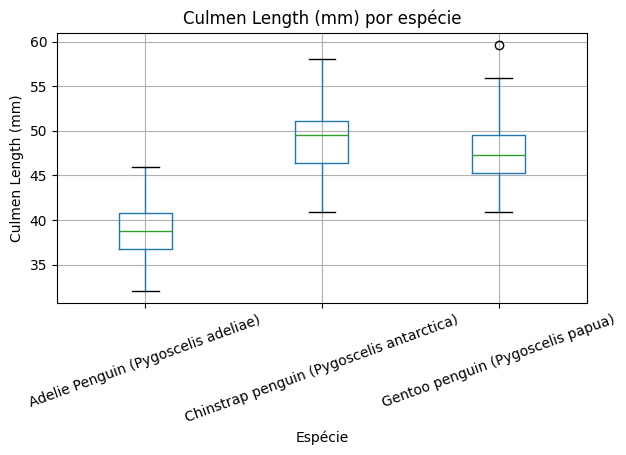

<Figure size 700x500 with 0 Axes>

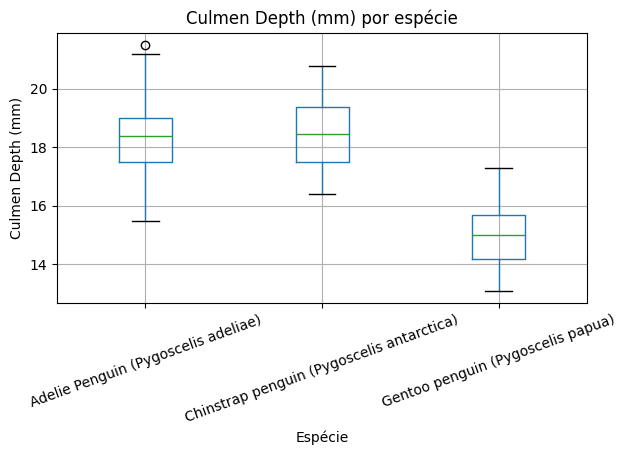

<Figure size 700x500 with 0 Axes>

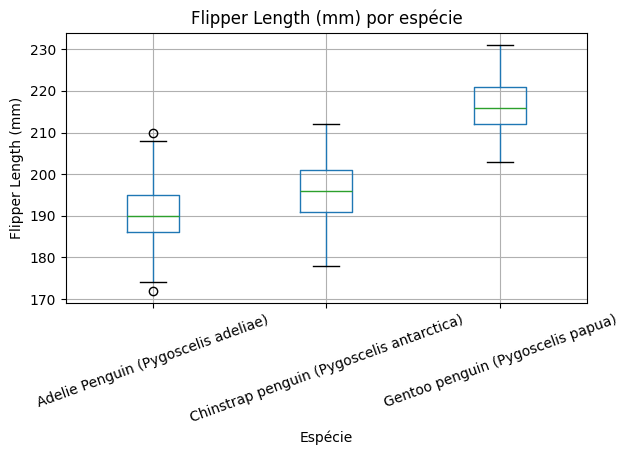

<Figure size 700x500 with 0 Axes>

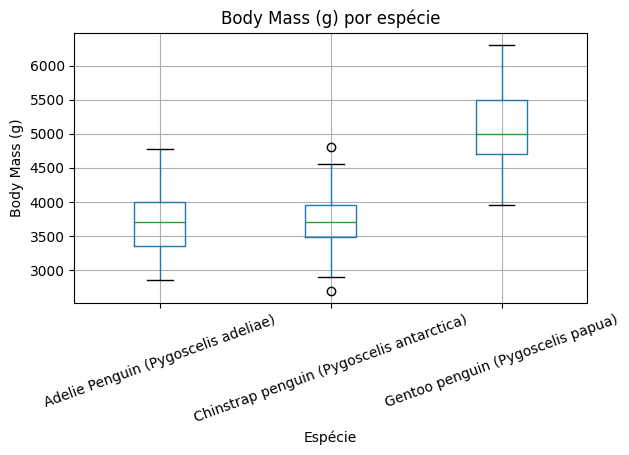

In [53]:
# Relação entre variáveis e target;

print('Relação entre variáveis e target: ')
print(' ')

for var in variaveis:
    plt.figure(figsize=(7,5))
    dataset.boxplot(column=var, by='Species')

    plt.xticks(rotation=20)
    plt.title(f'{var} por espécie')
    plt.suptitle('')
    plt.xlabel('Espécie')
    plt.ylabel(var)

    plt.tight_layout()
    plt.show()

A partir da análise dos boxplots, verifica-se que as distribuições das variáveis diferem entre as espécies de pinguins, evidenciando características morfológicas distintas entre os grupos. Além disso, observa-se a presença de valores atípicos (outliers) em algumas variáveis, indicando a existência de observações distantes do comportamento predominante dos dados.

In [54]:
# Valores ausentes
print('Valores ausentes:')
print(' ')

dataset.isna().sum()

Valores ausentes:
 


,0
studyName,0
Sample Number,0
Species,0
Region,0
Latitude,0
Longitude,0
Island,0
Stage,0
Individual ID,0
Clutch Completion,0


## 4.1 Síntese da análise exploratória

**Síntese:**  
> _A análise da distribuição da variável alvo (Species) indicou um leve desbalanceamento entre as classes. A espécie Adelie representa 44,19% dos registros, seguida por Gentoo com 36,05% e Chinstrap com 19,77%. Embora a classe Chinstrap possua menor quantidade de amostras, o desbalanceamento não é considerado severo e todas as espécies apresentam um número suficiente de observações para o treinamento dos modelos._

>_Em relação aos valores ausentes, identificou-se uma pequena quantidade de registros incompletos nas variáveis utilizadas pelo modelo. As variáveis Culmen Length (mm), Culmen Depth (mm), Flipper Length (mm) e Body Mass (g) apresentaram apenas 2 valores ausentes cada, enquanto a variável Sex apresentou 10 valores ausentes. Considerando a quantidade de registros, os dados faltantes são reduzidos e representam uma pequena parcela do conjunto de dados._

>_As variáveis numéricas apresentam escalas distintas, destacando-se Body Mass (g), cujos valores estão na ordem de milhares, enquanto as demais variáveis físicas apresentam valores na ordem de dezenas ou centenas. Não foram identificadas categorias raras entre as espécies, apesar de a espécie Chinstrap possuir menor número de registros em relação às demais. A análise exploratória também evidenciou diferenças nas características físicas dos indivíduos, especialmente no comprimento e profundidade do bico, comprimento da nadadeira e massa corporal, indicando uma boa capacidade de distinção entre as espécies. Esses padrões sugerem que os atributos selecionados possuem elevado poder discriminatório, favorecendo o desempenho de algoritmos de classificação, como Regressão Logística, KNN, SVM e Random Forest. A avaliação permitiu concluir que os dados se alinham com as estratégia de pré-processamento e modelagem definidas._


# 5. Preparação dos dados e divisão treino/teste

Nesta etapa, define-se quais colunas serão utilizadas, qual é o target e como os dados serão divididos.



In [55]:
# ---- Remover nulos ---- #
print("\nValores nulos:")

dataset = dataset.dropna(
    subset=[
        'Culmen Length (mm)',
        'Culmen Depth (mm)',
        'Flipper Length (mm)',
        'Body Mass (g)',
        'Sex',
        'Species'
    ]
)

print(dataset.isnull().sum())


Valores nulos:
studyName                0
Sample Number            0
Species                  0
Region                   0
Latitude                 0
Longitude                0
Island                   0
Stage                    0
Individual ID            0
Clutch Completion        0
Date Egg                 0
Culmen Length (mm)       0
Culmen Depth (mm)        0
Flipper Length (mm)      0
Body Mass (g)            0
Sex                      0
Delta 15 N (o/oo)        9
Delta 13 C (o/oo)        8
Comments               290
dtype: int64


In [56]:
# Tratamento variável Sex
dataset["Sex"] = dataset["Sex"].replace(".", np.nan)

# Remove linhas com valores ausentes em Sex
dataset = dataset.dropna(subset=["Sex"])

print(dataset["Sex"].unique())

['MALE' 'FEMALE']


In [57]:
# === Configuração do problema ===
# Ajuste estas variáveis para o seu dataset.

TARGET = "Species"
PROBLEM_TYPE = "classificacao"

if PROBLEM_TYPE != "clusterizacao":
    assert TARGET is not None and TARGET in dataset.columns, "Defina um TARGET válido."

features = [
        'Culmen Length (mm)',
        'Culmen Depth (mm)',
        'Flipper Length (mm)',
        'Body Mass (g)',
        'Sex'
    ]

print("Tipo de problema:", PROBLEM_TYPE)
print("Target:", TARGET)
print("Número de features:", len(features))
print("Features:", features)


Tipo de problema: classificacao
Target: Species
Número de features: 5
Features: ['Culmen Length (mm)', 'Culmen Depth (mm)', 'Flipper Length (mm)', 'Body Mass (g)', 'Sex']


In [58]:
# === Divisão dos dados ===

X = dataset[features].copy()
y = dataset[TARGET].copy()

stratify_arg = y

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED, stratify=stratify_arg
)

print("Treino:", X_train.shape, "| Teste:", X_test.shape)


Treino: (266, 5) | Teste: (67, 5)


In [59]:
print(X.isna().sum())

Culmen Length (mm)     0
Culmen Depth (mm)      0
Flipper Length (mm)    0
Body Mass (g)          0
Sex                    0
dtype: int64


## 5.1 Justificativa da divisão

>_Na etapa de tratamento dos dados, foram removidas as linhas que continham valores nulos nas variáveis de interesse, mantendo-se apenas os atributos Culmen Length (mm), Culmen Depth (mm), Flipper Length (mm), Body Mass (g), Sex e Species. Essa etapa  garante um conjunto de dados consistente, livre de valores ausentes nas variáveis selecionadas e adequado para o treinamento e a avaliação dos modelos de classificação. Sendo que Species é definido como target do problema e as outras colunas citadas, os features. Para variável Sex foi necessário remover os valores "." usados para representar valores ausentes._

>_Para a segregação dos dados, 20% das amostras foram destinadas ao conjunto de teste, enquanto os 80% restantes foram utilizados para treinamento. Para o dataset Palmer Penguins, a divisão de 80% para treinamento e 20% para teste é adequada, garantindo uma boa representatividade dos dados. Além disso, essa separação evita o vazamento de dados (data leakage), pois o modelo é treinado apenas com o conjunto de treinamento, enquanto o conjunto de teste é utilizado exclusivamente para a avaliação final._

>_A divisão foi realizada de forma estratificada com base na variável alvo, garantindo que ambos os conjuntos mantivessem aproximadamente a mesma distribuição das espécies presente no conjunto de dados original. Essa estratégia evita que alguma classe fique sub-representada em um dos conjuntos, contribuindo para uma avaliação mais confiável dos modelos de classificação. Além disso, foi definida uma semente para o gerador de números aleatórios, assegurando que a divisão dos dados seja reproduzível, ou seja, que o mesmo particionamento seja obtido em diferentes execuções do código._


# 6. Pré-processamento e pipeline




In [60]:
# Codifica Sex após a separação
X_train['Sex'] = X_train['Sex'].map({'MALE': 1, 'FEMALE': 0})
X_test['Sex'] = X_test['Sex'].map({'MALE': 1, 'FEMALE': 0})

# Colunas numéricas contínuas
num_cols = [
    'Culmen Length (mm)',
    'Culmen Depth (mm)',
    'Flipper Length (mm)',
    'Body Mass (g)'
]

# Padronização
scaler = StandardScaler()

X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test[num_cols] = scaler.transform(X_test[num_cols])

## 6.1 Decisões de pré-processamento

>_A variável categórica Sex foi convertida para um formato numérico, atribuindo-se o valor 1 para MALE e 0 para FEMALE. Essa transformação foi realizada porque a maioria dos algoritmos de aprendizado de máquina opera de forma mais eficiente com dados numéricos._

>_Como o conjunto de dados apresentava uma pequena quantidade de registros com valores nulos, optou-se pela remoção dessas amostras, evitando a introdução de valores artificiais que poderiam influenciar o desempenho dos modelos. A padronização foi realizada porque as variáveis numéricas apresentam escalas diferentes. Enquanto Body Mass (g) possui valores na ordem de milhares, as demais variáveis (Culmen Length, Culmen Depth e Flipper Length) apresentam valores na ordem de dezenas ou centenas. O uso do StandardScaler coloca todas as variáveis em uma escala semelhante, com média igual a zero e desvio padrão igual a um, evitando que atributos com maior magnitude exerçam influência desproporcional durante o treinamento dos modelos._

>_Após a separação dos dados em conjuntos de treinamento e teste, foi realizada a padronização das variáveis numéricas contínuas (Culmen Length, Culmen Depth, Flipper Length e Body Mass) utilizando o algoritmo StandardScaler. A variável categórica Sex, previamente codificada em valores numéricos, foi mantida sem padronização. O ajuste da transformação (fit) foi realizado apenas com o conjunto de treinamento, sendo posteriormente aplicado (transform) ao conjunto de teste. Esse procedimento garante que ambas as partições sejam escaladas de forma consistente e evita o vazamento de dados._



# 7. Baseline e modelos candidatos

Avaliação de modelo simples.




In [61]:
# ---- Definição de baseline e modelos candidatos ----

baseline = DummyClassifier(strategy="most_frequent")

modelos = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "KNN": KNeighborsClassifier(),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "SVM": SVC()
}


## 7.1 Justificativa dos modelos

>_Inicialmente foi definido um modelo baseline utilizando o DummyClassifier com a estratégia most_frequent, que realiza a previsão sempre da classe mais frequente do conjunto de treinamento, sendo coerente para o tipo de problema. Esse modelo serve como referência mínima de desempenho, permitindo verificar se os classificadores realmente aprenderam padrões presentes nos dados ou apenas obtiveram bons resultados devido às características do conjunto de dados. Em seguida, foram definidos cinco modelos candidatos: Regressão Logística, KNN, Decision Tree, Random Forest e SVM. O desempenho dos modelos foi comparado por meio das métricas de acurácia, precisão, recall e F1-score, possibilitando identificar quais algoritmos apresentaram melhor capacidade de classificação em relação ao baseline._

>_A Regressão Logística, o KNN e a SVM exigem padronização das variáveis por serem sensíveis à escala dos dados. Todos os modelos necessitam que as variáveis categóricas sejam convertidas para valores numéricos e que os dados não contenham valores ausentes. Devido ao pequeno tamanho do dataset Palmer Penguins, o custo computacional de todos os modelos é baixo e não representa uma limitação significativa._



# 8. Treinamento e avaliação inicial

Treinamento o baseline e os modelos candidatos. Comparação dos resultados iniciais.



In [62]:

# === Treinamento e avaliação inicial ===

resultados = []

# Baseline
inicio = time.time()

baseline.fit(X_train, y_train)

tempo_treinamento = time.time() - inicio

y_pred = baseline.predict(X_test)

resultados.append({
    "Modelo": "Baseline (Most Frequent)",
    "Accuracy": accuracy_score(y_test, y_pred),
    "Precision": precision_score(y_test, y_pred, average="weighted", zero_division=0),
    "Recall": recall_score(y_test, y_pred, average="weighted", zero_division=0),
    "F1-score": f1_score(y_test, y_pred, average="weighted", zero_division=0),
    "Tempo de treino (s)": round(tempo_treinamento, 4)
})

# Modelos candidatos
for nome, modelo in modelos.items():

    inicio = time.time()

    modelo.fit(X_train, y_train)

    tempo_treinamento = time.time() - inicio

    y_pred = modelo.predict(X_test)

    resultados.append({
        "Modelo": nome,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, average="weighted", zero_division=0),
        "Recall": recall_score(y_test, y_pred, average="weighted", zero_division=0),
        "F1-score": f1_score(y_test, y_pred, average="weighted", zero_division=0),
        "Tempo de treino (s)": round(tempo_treinamento, 4)
    })

# Tabela de resultados
resultados_df = (
    pd.DataFrame(resultados)
    .sort_values(by="Accuracy", ascending=False)
    .reset_index(drop=True)
)

print(resultados_df)



                     Modelo  Accuracy  Precision    Recall  F1-score  \
0       Logistic Regression  1.000000   1.000000  1.000000  1.000000   
1                       KNN  1.000000   1.000000  1.000000  1.000000   
2                       SVM  1.000000   1.000000  1.000000  1.000000   
3             Random Forest  0.985075   0.986070  0.985075  0.985201   
4             Decision Tree  0.955224   0.958955  0.955224  0.955570   
5  Baseline (Most Frequent)  0.432836   0.187347  0.432836  0.261505   

   Tempo de treino (s)  
0               0.0053  
1               0.0020  
2               0.0043  
3               0.1984  
4               0.0027  
5               0.0021  


## 8.1 Análise dos resultados iniciais

Interprete a tabela de resultados.

>_Nos resultados obtidos, o baseline apresentou acurácia de aproximadamente 43,28%, enquanto todos os modelos treinados alcançaram desempenho significativamente superior (95,5% a 100%), evidenciando que os algoritmos extraíram informações relevantes do conjunto de dados e não apenas se beneficiaram da distribuição das classes. Os modelos selecionados são adequados para um problema de classificação multiclasse, mesmo com um conjunto de dados pequeno, como o Palmer Penguins. Além disso, as métricas são adequadas a avaliação dos modelos._

>_Os resultados indicam que nenhum dos modelos apresentou underfitting, pois todos obtiveram desempenho elevado. Todos os modelos apresentaram tempos de treinamento muito baixos (inferiores a 0,2 segundo), o que é esperado devido ao pequeno tamanho do conjunto de dados. O Random Forest foi o modelo mais lento, mas ainda assim seu tempo de treinamento é não significativo. Durante a análise exploratória foi observado que as características físicas dos pinguins apresentam diferenças claras entre as espécies. Facilitando assim que os modelos de classificação obtivessem alto desempenho._


# 9. Validação e otimização de hiperparâmetros

Foi realizada a otimização dos hiperparâmetros do modelo Random Forest, por ter apresentado desempenho inferior aos melhores modelos na avaliação inicial. A busca foi realizada utilizando o RandomizedSearchCV, testando diferentes combinações dos hiperparâmetros n_estimators, max_depth, min_samples_split, min_samples_leaf, max_features e bootstrap. Como estratégia de validação, foi empregada validação cruzada estratificada com 5 folds (Stratified 5-Fold Cross Validation), preservando a proporção das classes em cada divisão. A seleção da melhor configuração foi guiada pela métrica de acurácia (accuracy).


In [42]:
N_ITER_SEARCH = 20
search = None

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=SEED
)

param_dist = {
    "n_estimators": randint(20, 150),
    "max_depth": [None, 5, 10, 15, 20],
    "min_samples_split": randint(2, 10),
    "min_samples_leaf": randint(1, 5),
    "max_features": ["sqrt", "log2", None],
    "bootstrap": [True, False]
}

search = RandomizedSearchCV(
    estimator=RandomForestClassifier(random_state=SEED),
    param_distributions=param_dist,
    n_iter=N_ITER_SEARCH,
    cv=cv,
    scoring="accuracy",
    random_state=SEED,
    n_jobs=-1
)

search.fit(X_train, y_train)

print("Tempo: ", tempo_treinamento)

print("Melhores parâmetros:")
print(search.best_params_)

print("\nMelhor acurácia (CV):")
print(search.best_score_)

best_rf = search.best_estimator_

y_pred = best_rf.predict(X_test)

print("\nDesempenho no conjunto de teste")
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred, average="weighted", zero_division=0))
print("Recall:", recall_score(y_test, y_pred, average="weighted", zero_division=0))
print("F1:", f1_score(y_test, y_pred, average="weighted", zero_division=0))




Tempo:  0.001958131790161133
Melhores parâmetros:
{'bootstrap': False, 'max_depth': 5, 'max_features': 'log2', 'min_samples_leaf': 1, 'min_samples_split': 3, 'n_estimators': 72}

Melhor acurácia (CV):
0.9812019566736548

Desempenho no conjunto de teste
Accuracy: 0.9850746268656716
Precision: 0.9860696517412935
Recall: 0.9850746268656716
F1: 0.9852010365594893


## 9.1 Discussão da otimização

>_A maioria dos modelos avaliados na etapa inicial já apresentava desempenho máximo, alcançando 100% de acurácia, o que indicava pouca margem para ganhos por meio da otimização de hiperparâmetros. Ainda assim, foi realizada a otimização do Random Forest, por ser o modelo com melhor potencial de melhoria entre aqueles que não atingiram desempenho máximo. Após a busca, o modelo manteve praticamente o mesmo desempenho observado inicialmente, com 98,51% de acurácia no conjunto de teste, indicando que a otimização não proporcionou ganhos significativos._

>_A busca foi realizada com 20 combinações aleatórias e validação cruzada estratificada de 5 folds, sendo limitada para reduzir o custo computacional, embora o pequeno tamanho da base de dados permitisse uma exploração maior do espaço de hiperparâmetros. Os valores encontrados (n_estimators = 72, max_depth = 5, min_samples_split = 3, min_samples_leaf = 1, max_features = "log2" e bootstrap = False) são coerentes, pois representam uma floresta de tamanho moderado e árvores menos profundas, favorecendo a generalização e reduzindo o risco de sobreajuste._

# 10. Avaliação final no conjunto de teste






In [43]:
# === Avaliação final ===
# Baseline

baseline = DummyClassifier(strategy="most_frequent")
baseline.fit(X_train, y_train)

y_pred_baseline = baseline.predict(X_test)

baseline_acc = accuracy_score(y_test, y_pred_baseline)
baseline_prec = precision_score(y_test, y_pred_baseline, average="weighted", zero_division=0)
baseline_rec = recall_score(y_test, y_pred_baseline, average="weighted", zero_division=0)
baseline_f1 = f1_score(y_test, y_pred_baseline, average="weighted", zero_division=0)

# Modelo Final
modelo_final = SVC()

modelo_final.fit(X_train, y_train)

y_pred = modelo_final.predict(X_test)

svm_acc = accuracy_score(y_test, y_pred)
svm_prec = precision_score(y_test, y_pred, average="weighted")
svm_rec = recall_score(y_test, y_pred, average="weighted")
svm_f1 = f1_score(y_test, y_pred, average="weighted")

print("=== Comparação: Baseline x SVM ===")
print(f"{'Métrica':<12}{'Baseline':>12}{'SVM':>12}")
print(f"{'Accuracy':<12}{baseline_acc:>12.4f}{svm_acc:>12.4f}")
print(f"{'Precision':<12}{baseline_prec:>12.4f}{svm_prec:>12.4f}")
print(f"{'Recall':<12}{baseline_rec:>12.4f}{svm_rec:>12.4f}")
print(f"{'F1-score':<12}{baseline_f1:>12.4f}{svm_f1:>12.4f}")


=== Comparação: Baseline x SVM ===
Métrica         Baseline         SVM
Accuracy          0.4328      1.0000
Precision         0.1873      1.0000
Recall            0.4328      1.0000
F1-score          0.2615      1.0000


## 10.1 Análise de erros e limitações

>_O modelo selecionado para avaliação final foi a Support Vector Machine (SVM), por apresentar 100% de acurácia na avaliação inicial e um dos menores tempos de treinamento entre os modelos candidatos. O modelo SVM apresentou desempenho significativamente superior ao baseline em todas as métricas avaliadas. Enquanto o baseline obteve 43,28% de acurácia, a SVM alcançou 100% de acurácia, precisão, recall e F1-score, demonstrando que foi capaz de aprender os padrões presentes nos dados e realizar a classificação das espécies com elevada precisão. Esse resultado confirma que o modelo supera amplamente uma estratégia simples baseada na classe mais frequente._

>_Não foram observados indícios de underfitting, uma vez que o modelo apresentou desempenho elevado em todas as métricas. Também não há evidências claras de overfitting, pois a avaliação foi realizada em um conjunto de teste separado do treinamento._

>_Apesar do excelente desempenho obtido, o conjunto Palmer Penguins é relativamente pequeno e apresenta características físicas que distinguem claramente as espécies, tornando a tarefa de classificação menos complexa. Assim, o desempenho observado pode não se repetir em conjuntos de dados maiores ou com maior sobreposição entre as classes._

>_O modelo não deve ser utilizado diretamente em conjuntos de dados muito diferentes do Palmer Penguins, como aqueles contendo espécies não presentes no treinamento, características físicas com distribuições distintas ou dados coletados em outras regiões sem uma nova etapa de treinamento e validação. Além disso, por ter sido desenvolvido com um conjunto de dados pequeno e específico, seu desempenho pode não se manter em aplicações reais com dados mais variados ou sujeitos a ruídos. Portanto, antes de sua utilização em outro contexto, é necessário reavaliar e, se necessário, retreinar o modelo com dados representativos do novo cenário._


# 11. Comparação final dos modelos

Apresente uma síntese comparativa.

| Modelo | Accuracy | Precision | Recall | F1-score | Tempo de treino | Observações |
|---------|---------:|----------:|-------:|---------:|----------------:|-------------|
| Baseline | _0.43_ | _0.19_ | _0.43_ | _0.26_ | _0.0013_ |  |
| Logistic Regression | 1.00 | 1.00 | 1.00 | 1.00 | _0.0066_ |  |
| KNN | 1.00 | 1.00 | 1.00 | 1.00 | _0.0028_ |  |
| SVM | 1.00 | 1.00 | 1.00 | 1.00 | _0.0027_ | _Modelo selecionado_ |
| Random Forest | 0.985 | 0.986 | 0.985 | 0.985 | _0.1889_ |  |
| Decision Tree | 0.955 | 0.959 | 0.955 | 0.9556 | _0.0037_ |  |





# 12. Boas práticas e rastreabilidade

Decisões importantes do projeto.

| Decisão | Justificativa | Impacto esperado |
|---|---|---|
| _Definição da SEED = 42_ | _Garantir a reprodutibilidade dos experimentos, mantendo a mesma divisão dos dados e os mesmos resultados entre execuções_ | _Facilitar a comparação entre modelos_ |
| _Remoção de valores ausentes_ | _Os algoritmos utilizados não lidam diretamente com valores nulos_ | _Evitar erros de execução_ |
| _Seleção de características_ | _Selecionar apenas as características que influenciam no tipo de espécie_ | _Reduzir complexidade do modelo_ |
| _Conversão da variável Sex para valores numéricos_ | _Alguns algoritmos requerem entradas numéricas_ | _Permite que a variável categórica seja utilizada no treinamento dos modelos_ |
| _Separação entre treino e teste (80% / 20%)_ | _Avaliar a capacidade de generalização do modelo_ | _Garantir que o modelo seja testado com dados desconhecidos_ |
| _Teste de múltiplos modelos (Regressão Logística, KNN, Árvore de Decisão, Random Forest e SVM)_ | _Comparar diferentes abordagens para identificar a mais adequada ao problema_ | _Possibilita selecionar o modelo com melhor equilíbrio entre desempenho e custo computacional_ |
| _Avaliação utilizando Accuracy, Precision, Recall e F1-score_ | _Essas métricas fornecem uma visão abrangente do desempenho em um problema de classificação multiclasse_ | _Permite comparar os modelos de forma mais completa do que apenas pela acurácia_ |
| _Escolha da SVM como modelo final_ | _Obteve 100% de acurácia, precisão, recall e F1-score, além de baixo tempo de treinamento_ | _Seleção de um modelo com excelente desempenho e boa eficiência computacional_ |
| _Otimização dos hiperparâmetros do Random Forest_ | _Era o modelo com maior potencial de melhoria entre aqueles que não atingiram desempenho máximo_ | _Buscar uma configuração que melhorasse a capacidade de generalização do modelo_ |
| _Comparação do tempo de treinamento_ | _Avaliar tempo de execução e possível impacto computacional_ | _Auxilia na escolha de modelos mais eficientes. Os tempos observados variaram aproximadamente de 0,0027 s (SVM) até aproximadamente 0,19 s (Random Forest)_ |


# 13. Conclusão

Com o desenvolvimento deste projeto, foi possível aplicar diferentes modelos de classificação ao dataset Palmer Penguins e obter boa capacidade de generalização para a identificação de novos indivíduos. Todos os modelos treinados apresentaram elevado desempenho nas métricas avaliadas, superando amplamente o baseline. Entre eles, foi selecionado o modelo Support Vector Machine (SVM), por alcançar 100% de acurácia, precisão, recall e F1-score, além de apresentar um baixo tempo de treinamento.

Apesar dos excelentes resultados, algumas limitações foram identificadas. Como a maioria dos modelos já apresentou desempenho máximo na avaliação inicial, houve pouca margem para melhorias por meio da otimização de hiperparâmetros. Além disso, o conjunto de dados possui um número relativamente reduzido de amostras e contempla apenas três espécies de pinguins, o que pode limitar a capacidade de generalização da solução para cenários mais diversos.

Como trabalhos futuros, seria interessante ampliar a base de dados com um maior número de amostras e incluir informações de outras espécies ou populações de pinguins. Também seria possível avaliar outros algoritmos, realizar ajustes mais abrangentes de hiperparâmetros e validar o modelo em novos conjuntos de dados, permitindo verificar sua robustez e desempenho em diferentes contextos.




